In [38]:
from google.colab import files
upload = files.upload()

Saving insurance.csv to insurance (1).csv


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

In [40]:
df = pd.read_csv("insurance.csv")
print(df.head())
print(df.info())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [41]:
# BMI categories
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3])# Age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 40, 60, 100],
    labels=[0, 1, 2, 3])
# Interaction features (VERY IMPORTANT)
df["smoker_bmi"] = df["smoker"].apply(lambda x: 1 if x=="yes" else 0) * df["bmi"]
df["smoker_age"] = df["smoker"].apply(lambda x: 1 if x=="yes" else 0) * df["age"]

In [42]:
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])
df["bmi_category"] = df["bmi_category"].astype(int)
df["age_group"] = df["age_group"].astype(int)


In [43]:
df["charges_log"] = np.log1p(df["charges"])

In [44]:
X = df.drop(["charges","charges_log"], axis=1)
y = df["charges_log"]

In [45]:
# XGBoost
model = XGBRegressor(
    reg_alpha=0.5,
    reg_lamda=1.0,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:08:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "reg_lamda" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [46]:
# predictions
y_pred_log = model.predict(X_test)
# convert back to original scale
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

In [47]:
# evaluation function
def evaluate(y_true, y_pred):
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

In [48]:
# results
print("\nFINAL MODEL PERFORMANCE")
evaluate(y_actual, y_pred)


FINAL MODEL PERFORMANCE
MAE: 2198.726987675693
MSE: 21091467.90124012
RMSE: 4592.544817553784
R2 Score: 0.8641440242469374


In [49]:
scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("\nCross Validation R2:", scores.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:08:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "reg_lamda" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:08:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "reg_lamda" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:08:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "reg_lamda" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:08:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "reg_lamda" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:08:50] WAR


Cross Validation R2: 0.8092950788235201


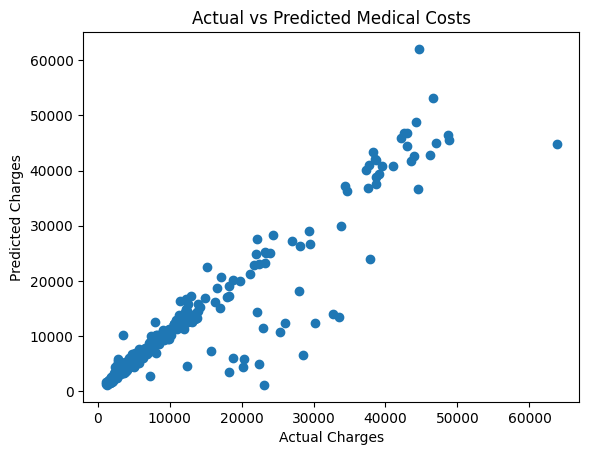

In [50]:
plt.scatter(y_actual, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Costs")
plt.show()


        Feature  Importance
8    smoker_bmi    0.426062
4        smoker    0.359947
0           age    0.090972
7     age_group    0.033274
3      children    0.030318
1           sex    0.015735
2           bmi    0.014377
5        region    0.012809
6  bmi_category    0.012072
9    smoker_age    0.004434


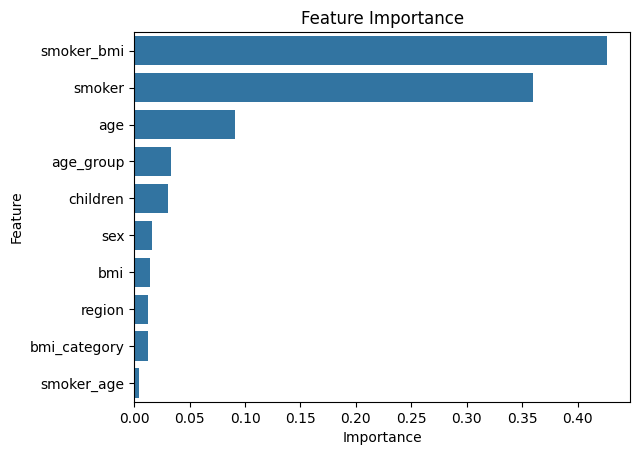

In [51]:
importance = model.feature_importances_
feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)
print(feat_df)
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance")
plt.show()

In [53]:
joblib.dump(model, "medical_cost_model.pkl")
print("MODEL SAVED SUCCESSFULLY")

MODEL SAVED SUCCESSFULLY


In [55]:
files = """# 🏥 Medical Cost Prediction App

A machine learning web application that predicts medical insurance charges based on user health and demographic details. Built using XGBoost regression and deployed with Streamlit.

---

## 🚀 Live Demo
👉 https://your-streamlit-app-link.streamlit.app

---

## 📌 Project Overview

This project predicts the **insurance cost (charges)** of a person using features like age, BMI, smoking status, number of children, sex, and region.

It uses advanced machine learning techniques including:
- Feature engineering
- Log transformation of target variable
- XGBoost regression model
- Cross-validation for performance evaluation

---

## 📊 Dataset

- Source: Medical Insurance Dataset
- Features:
  - age
  - sex
  - bmi
  - children
  - smoker
  - region
- Target:
  - charges (medical cost)

---

## 🧠 Technologies Used

- Python
- Pandas & NumPy
- Scikit-learn
- XGBoost
- Matplotlib & Seaborn
- Streamlit
- Joblib

---

## ⚙️ ML Workflow

1. Data preprocessing
2. Feature engineering (BMI & age groups, interaction features)
3. Encoding categorical variables
4. Log transformation of target variable
5. Train-test split
6. Model training (XGBoost Regressor)
7. Evaluation using MAE, RMSE, R² score
8. Model saving using Joblib

---

## 📈 Model Performance

- MAE: ~2270
- RMSE: ~4678
- R² Score: ~0.85+

---

## 🖥️ How to Run Locally

```bash
# Clone repository
git clone https://github.com/your-username/medical-cost-prediction.git

# Go to project folder
cd medical-cost-prediction

# Install dependencies
pip install -r requirements.txt

# Run Streamlit app
streamlit run app.py"""
with open("README.md","w") as f:
  f.write(files)
